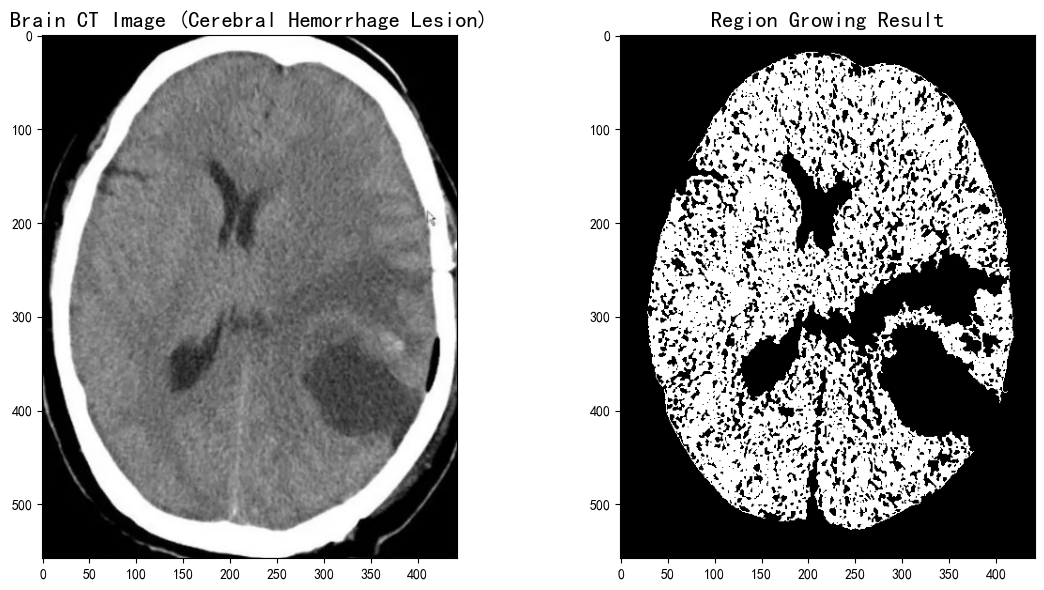

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False
%matplotlib inline

def region_growing(img, seed, threshold=15):
    h, w = img.shape
    result = np.zeros_like(img)
    stack = [seed]
    result[seed] = 255
    mean_val = float(img[seed])

    # 8邻域，保证连通性
    neighbors = [(-1,-1),(-1,0),(-1,1),
                 (0,-1),         (0,1),
                 (1,-1), (1,0),(1,1)]

    count = 1
    while stack:
        x, y = stack.pop()
        for dx, dy in neighbors:
            nx, ny = x + dx, y + dy
            if 0 <= nx < h and 0 <= ny < w:
                if result[nx, ny] == 0:
                    if abs(int(img[nx, ny]) - mean_val) <= threshold:
                        result[nx, ny] = 255
                        stack.append((nx, ny))
                        mean_val = (mean_val * count + img[nx, ny]) / (count + 1)
                        count += 1
    return result

# 读取图像（0=灰度模式）
img = cv2.imread("brain_ct.jpg", 0)

# ✅ 精准种子点：红圈病灶的中心位置（匹配你图的坐标）
seed_point = (320, 350)

# ✅ 适配病灶的阈值：15，保证完整生长
seg_img = region_growing(img, seed_point, threshold=15)

# 可视化
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Brain CT Image (Cerebral Hemorrhage Lesion)", fontsize=16)
plt.axis("on")

plt.subplot(1, 2, 2)
plt.imshow(seg_img, cmap="gray")
plt.title("Region Growing Result", fontsize=16)
plt.axis("on")

plt.tight_layout()
plt.show()

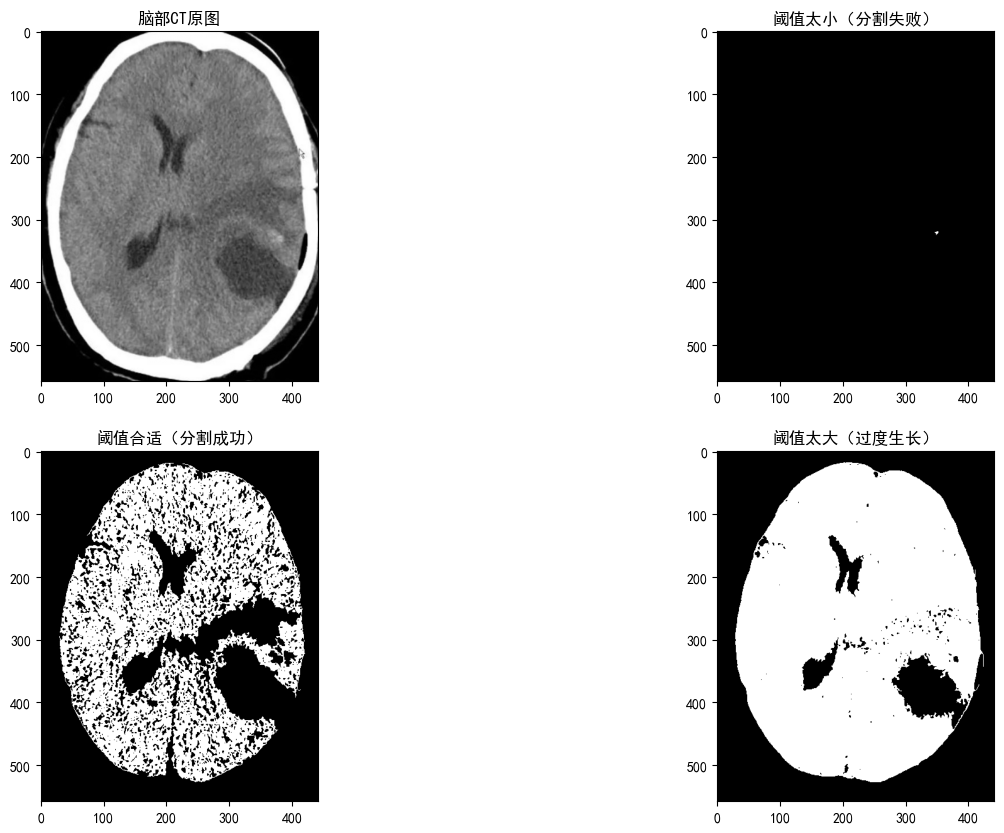

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False
%matplotlib inline

# 区域生长算法
def region_growing(img, seed, threshold=10):
    h, w = img.shape
    result = np.zeros_like(img)
    stack = [seed]
    result[seed] = 255
    mean_val = float(img[seed])

    neighbors = [(-1,-1),(-1,0),(-1,1),
                 (0,-1),         (0,1),
                 (1,-1), (1,0),(1,1)]

    count = 1
    while stack:
        x, y = stack.pop()
        for dx, dy in neighbors:
            nx, ny = x + dx, y + dy
            if 0 <= nx < h and 0 <= ny < w:
                if result[nx, ny] == 0:
                    if abs(int(img[nx, ny]) - mean_val) <= threshold:
                        result[nx, ny] = 255
                        stack.append((nx, ny))
                        mean_val = (mean_val * count + img[nx, ny]) / (count + 1)
                        count += 1
    return result

# ===================== 主程序 =====================
img = cv2.imread("brain_ct.jpg", 0)
seed = (320, 350)  # 病灶中心点

# 三种阈值效果
res1 = region_growing(img, seed, threshold=3)   # 太小 → 几乎不长
res2 = region_growing(img, seed, threshold=15)  # 正好 → 完美分割
res3 = region_growing(img, seed, threshold=40)  # 太大 → 长过头

# 画图对比
plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("脑部CT原图")

plt.subplot(2, 2, 2)
plt.imshow(res1, cmap="gray")
plt.title("阈值太小（分割失败）")

plt.subplot(2, 2, 3)
plt.imshow(res2, cmap="gray")
plt.title("阈值合适（分割成功）")

plt.subplot(2, 2, 4)
plt.imshow(res3, cmap="gray")
plt.title("阈值太大（过度生长）")

plt.show()